# Source-Target betweenness centrality for BANC

2025/10/31

Zuoyu Zhang & Tatsuo Okubo

In [1]:
import graph_tool.all as gt
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import sqlite3

# Load necessary data
- BANC `edgelist_simple`
- `node_mapping`: dictionary that allows mapping betweeen node ID and node index in both directions

In [2]:
df = pd.read_csv("../Data/edgelist_simple.csv")
print(f"Number of connections: {len(df)}")

Number of connections: 10298797


In [3]:
with open('../Data/node_mapping.pkl', 'rb') as f:
    loaded_data = pickle.load(f)
node_to_index = loaded_data['node_to_index']

In [4]:
unique_nodes = pd.unique(df[['pre', 'post']].values.ravel('K'))
n = len(unique_nodes)
print(f"Number of unique nodes in the network: {n}")

Number of unique nodes in the network: 137418


# Create a directed using igraph

In [5]:
df['pre_id'] = df['pre'].map(node_to_index)
df['post_id'] = df['post'].map(node_to_index)

numeric_edges = df[['pre_id', 'post_id']].values

In [6]:
g = ig.Graph(n, edges=numeric_edges, directed=True)

In [7]:
print(f"Number of nodes: {g.vcount()}, Number of edges: {g.ecount()}")

Number of nodes: 137418, Number of edges: 10298797


# Search the afferents and efferents from the meta data

In [8]:
# load the BANC 626 meta data
con = sqlite3.connect("../Data/banc_626_data.sqlite")
cursor = con.cursor()

In [9]:
cursor.execute(
    "SELECT super_class, COUNT(*) as count FROM meta WHERE super_class LIKE ? GROUP BY super_class", 
    ('%sensory%',) 
)
records = cursor.fetchall()
print(records)

cursor.execute(
    "SELECT root_626 FROM meta WHERE super_class LIKE ?", 
    ('%sensory%',) 
)
afferent = cursor.fetchall()
print(len(afferent))

[('sensory', 13889), ('sensory_ascending', 511), ('sensory_descending', 13)]
14413


In [10]:
cursor.execute("""
    SELECT super_class, COUNT(*) as count 
    FROM meta 
    WHERE super_class LIKE ? OR super_class LIKE ? GROUP BY super_class
""", ('%motor%', '%visceral_circulatory%'))
records = cursor.fetchall()
print(records)

cursor.execute(
    "SELECT root_626 FROM meta WHERE super_class LIKE ? OR super_class LIKE ?", 
    ('%motor%', '%visceral_circulatory%')
)
efferent = cursor.fetchall()
print(len(efferent))

[('ascending_visceral_circulatory', 5), ('motor', 833), ('visceral_circulatory', 188)]
1026


In [11]:
afferent = [int(i[0]) for i in afferent]
efferent = [int(i[0]) for i in efferent]
afferent_ids = [node_to_index[i] for i in afferent if node_to_index.get(i, -1)!=-1]
efferent_ids = [node_to_index[i] for i in efferent if node_to_index.get(i, -1)!=-1]

In [12]:
len(afferent_ids)

13819

In [13]:
len(efferent_ids)

1026

In [14]:
len(afferent) - len(afferent_ids)  # these afferents were found in the meta data, but not in the edgelist_simple

594

In [15]:
len(efferent) - len(efferent_ids)  # all the efferents from the meta data was found in the edgelist_simple

0

# Calculate the source-target betweeness centrality

This following takes times to run (a few hours depending on your machine). We recommend to run this part separately via a script in "./igraph/run_igraph".

In [16]:
# vertex_betweenness = g.betweenness(
#     vertices=None,
#     directed=True,
#     cutoff=None,
#     weights=None,
#     sources=afferent_ids,
#     targets=efferent_ids)

# Load the results

In [17]:
df_betweenness = pd.read_csv("../Results/betweenness_afferent_to_efferent.csv")

In [18]:
# display the top 20 nodes with highest betweenness centrality
df_betweenness.sort_values("betweenness", ascending=False).head(20)

,vertex_id,root_626,super_class,cell_type,betweenness
2125,2125,720575941529494660,descending,DNc01,404458.886295
17648,17648,720575941527162905,descending,DNb05,293801.583195
3906,3906,720575941691706264,ascending,AN19B001_a,281561.330433
23870,23870,720575941447863316,descending,DNb05,277809.652733
294,294,720575941626272650,ascending,AN19B001_a,251011.936513
296,296,720575941508609665,ascending,AN19B001_b,152273.001471
2086,2086,720575941408568750,ascending,AN19B001_b,136086.977392
19408,19408,720575941611304937,descending,DNc01,117988.771937
2541,2541,720575941546668988,descending,DNpe053,115787.246289
7608,7608,720575941519463278,descending,DNg108,111678.831320


# Visualize the betweenness centrality by super class

In [19]:
order = (
    df_betweenness.groupby("super_class")["betweenness"]
      .median()
      .sort_values(ascending=False)
      .index
)

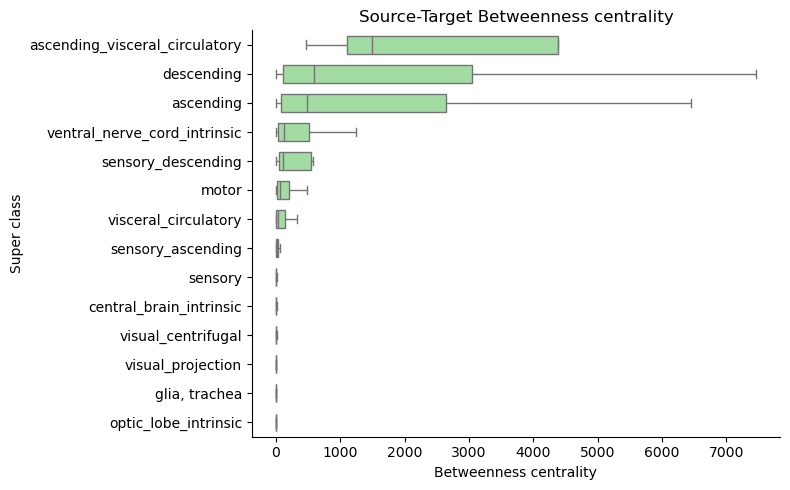

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_betweenness,
    x="betweenness",
    y="super_class",
    order=order,
    width=0.6,
    showfliers=False,  # note: there are some neurons with extremely high values
    color=(0.6, 0.9, 0.6),
)
plt.xlabel("Betweenness centrality")
plt.ylabel("Super class")
plt.title("Source-Target Betweenness centrality")
plt.tight_layout()
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)
plt.show()